In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_parquet(
    "data/artifacts/03_train.parquet"
)

print("Shape:", train.shape)
display(train.head())

Shape: (67533, 42)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_lat,customer_lng,...,total_product_volume_cm3,avg_product_photos_qty,avg_product_name_length,avg_product_description_length,seller_customer_distance_km,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_delayed
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,-20.585396,-47.863156,...,12288.0,1.0,34.0,1036.0,566.040211,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,-23.581321,-46.635726,...,4096.0,3.0,63.0,1642.0,708.535291,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,-28.291275,-53.501401,...,4096.0,1.0,39.0,518.0,915.734331,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,-22.936855,-43.359961,...,3332.0,1.0,25.0,823.0,358.782919,b8b8726af116a5cfb35b0315ecef9172,22770,rio de janeiro,RJ,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,-30.040958,-51.212970,...,4160.0,1.0,39.0,141.0,818.048765,61db744d2f835035a5625b59350c6b63,90040,porto alegre,RS,0


In [2]:
print(train.dtypes)

order_id                                  object
customer_id                               object
order_status                              object
order_purchase_timestamp          datetime64[ns]
order_approved_at                         object
order_delivered_carrier_date              object
order_delivered_customer_date     datetime64[ns]
order_estimated_delivery_date     datetime64[ns]
customer_lat                             float64
customer_lng                             float64
customer_geo_points                      float64
seller_lat                               float64
seller_lng                               float64
seller_geo_points                        float64
num_sellers                              float64
num_seller_states                        float64
num_seller_cities                        float64
total_price                              float64
total_freight                            float64
num_items                                float64
num_unique_products 

In [3]:
print("\nعدد الصفوف:", train.shape[0])
print("عدد الأعمدة:", train.shape[1])


عدد الصفوف: 67533
عدد الأعمدة: 42


In [4]:
missing = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing[missing > 0]
)

avg_product_description_length    1197
avg_product_photos_qty            1197
avg_product_name_length           1197
num_reviews                        515
avg_review_score                   515
seller_customer_distance_km        344
customer_lat                       181
customer_lng                       181
customer_geo_points                181
seller_lat                         164
seller_lng                         164
avg_product_weight_g                16
avg_product_width_cm                16
avg_product_height_cm               16
avg_product_length_cm               16
order_approved_at                   14
total_payment                        1
order_delivered_carrier_date         1
num_payment_types                    1
num_payment_records                  1
dtype: int64

In [5]:
categorical_cols = [
    "order_status",
    "customer_city",
    "customer_state"
]

for col in categorical_cols:

    print("\n" + "=" * 60)
    print("العمود:", col)
    print("عدد القيم المختلفة:", train[col].nunique())

    display(
        train[col]
        .value_counts(dropna=False)
        .head(15)
    )


العمود: order_status
عدد القيم المختلفة: 2


order_status
delivered    67527
canceled         6
Name: count, dtype: int64


العمود: customer_city
عدد القيم المختلفة: 3747


customer_city
sao paulo                9921
rio de janeiro           4780
belo horizonte           1869
brasilia                 1395
curitiba                 1020
porto alegre              975
campinas                  967
salvador                  823
guarulhos                 724
sao bernardo do campo     622
niteroi                   559
santo andre               518
osasco                    485
santos                    456
fortaleza                 454
Name: count, dtype: int64


العمود: customer_state
عدد القيم المختلفة: 27


customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
PE     1117
CE      948
PA      718
MT      640
MA      548
Name: count, dtype: int64

In [6]:
status_delay = pd.crosstab(
    train["order_status"],
    train["is_delayed"],
    normalize="index"
).mul(100).round(2)

display(status_delay)

is_delayed,0,1
order_status,,
canceled,83.33,16.67
delivered,90.97,9.03


In [7]:
numeric_features = [
    "total_price",
    "total_freight",
    "num_items",
    "seller_customer_distance_km"
]

for col in numeric_features:

    print("\n" + "=" * 60)
    print(col)

    display(
        train.groupby("is_delayed")[col]
        .agg(
            count="count",
            mean="mean",
            median="median",
            std="std"
        )
    )


total_price


,count,mean,median,std
is_delayed,,,,
0,61436,134.506741,84.99,203.737309
1,6097,149.767376,89.99,218.801051



total_freight


,count,mean,median,std
is_delayed,,,,
0,61436,21.950632,16.60,19.604236
1,6097,25.202941,18.12,23.414034



num_items


,count,mean,median,std
is_delayed,,,,
0,61436,1.144834,1.0,0.544545
1,6097,1.114319,1.0,0.510603



seller_customer_distance_km


,count,mean,median,std
is_delayed,,,,
0,61130,598.208414,437.063057,585.272072
1,6059,778.000656,550.654342,670.666585


In [8]:
train["purchase_year"] = (
    train["order_purchase_timestamp"].dt.year
)

train["purchase_month"] = (
    train["order_purchase_timestamp"].dt.month
)

train["purchase_weekday"] = (
    train["order_purchase_timestamp"].dt.dayofweek
)

In [9]:
monthly_delay = (
    train.groupby("purchase_month")["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
)

display(monthly_delay)

purchase_month
1      6.23
2     13.42
3     17.15
4      7.02
5      3.61
6      3.86
7      3.43
8      3.32
9      5.23
10     5.05
11    14.31
12     8.38
Name: is_delayed, dtype: float64

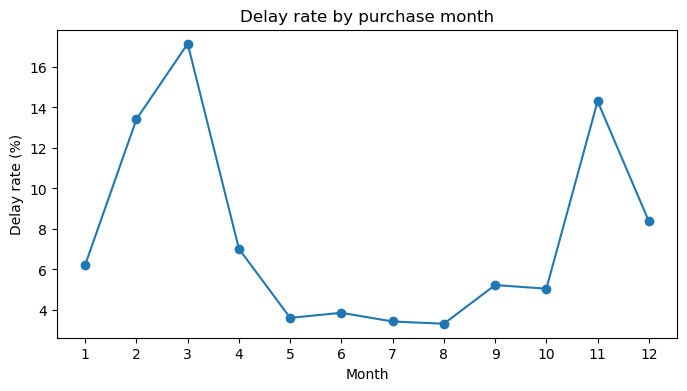

In [10]:
plt.figure(figsize=(8, 4))

monthly_delay.plot(
    kind="line",
    marker="o"
)

plt.title("Delay rate by purchase month")
plt.xlabel("Month")
plt.ylabel("Delay rate (%)")
plt.xticks(range(1, 13))

plt.show()

In [11]:
weekday_delay = (
    train.groupby("purchase_weekday")["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
)

display(weekday_delay)

purchase_weekday
0    10.02
1     9.26
2     8.61
3     8.29
4     9.47
5     8.97
6     8.38
Name: is_delayed, dtype: float64

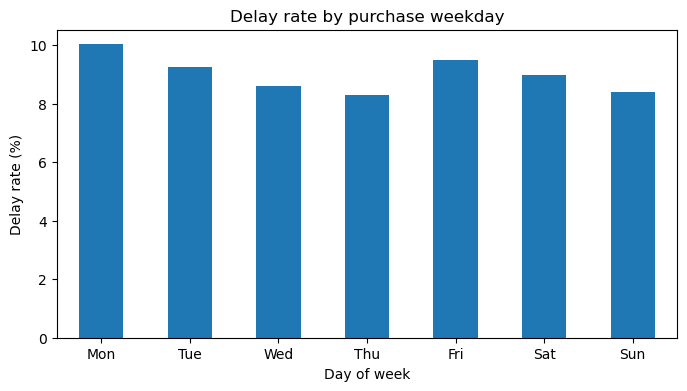

In [12]:
plt.figure(figsize=(8, 4))

weekday_delay.plot(
    kind="bar"
)

plt.title("Delay rate by purchase weekday")
plt.xlabel("Day of week")
plt.ylabel("Delay rate (%)")
plt.xticks(range(7), [
    "Mon", "Tue", "Wed", "Thu",
    "Fri", "Sat", "Sun"
], rotation=0)

plt.show()

In [13]:
state_delay = (
    train.groupby("customer_state")["is_delayed"]
    .agg(
        delay_rate="mean",
        orders="count"
    )
)

state_delay["delay_rate"] = (
    state_delay["delay_rate"] * 100
).round(2)

display(
    state_delay.sort_values(
        "delay_rate",
        ascending=False
    ).head(15)
)

,delay_rate,orders
customer_state,,
AL,27.85,298
MA,21.53,548
CE,18.25,948
RR,17.24,29
SE,17.07,246
PI,16.67,348
RJ,16.58,8967
BA,15.00,2307
PA,13.37,718


In [14]:
train["distance_band"] = pd.cut(
    train["seller_customer_distance_km"],
    bins=[0, 100, 300, 500, 1000, 2000, np.inf],
    labels=[
        "0-100",
        "100-300",
        "300-500",
        "500-1000",
        "1000-2000",
        "2000+"
    ]
)
distance_delay = (
    train.groupby("distance_band", observed=False)["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
)

display(distance_delay)

distance_band
0-100         4.85
100-300       6.90
300-500       9.23
500-1000      9.98
1000-2000    12.09
2000+        15.24
Name: is_delayed, dtype: float64

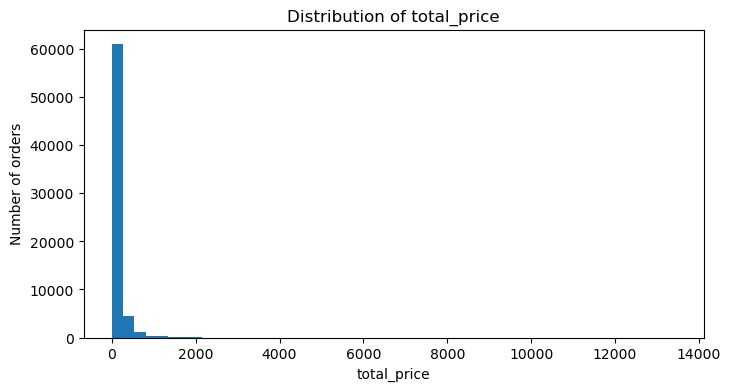

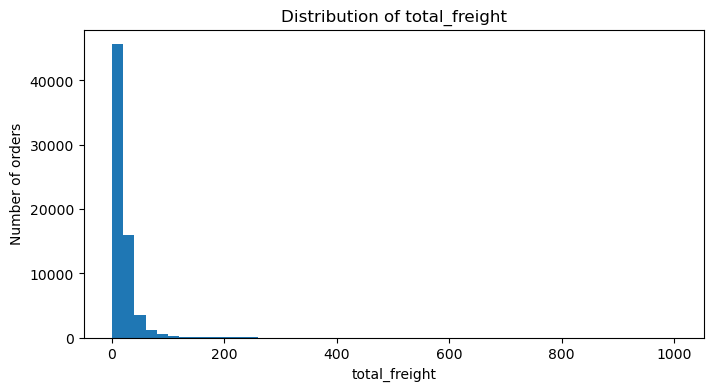

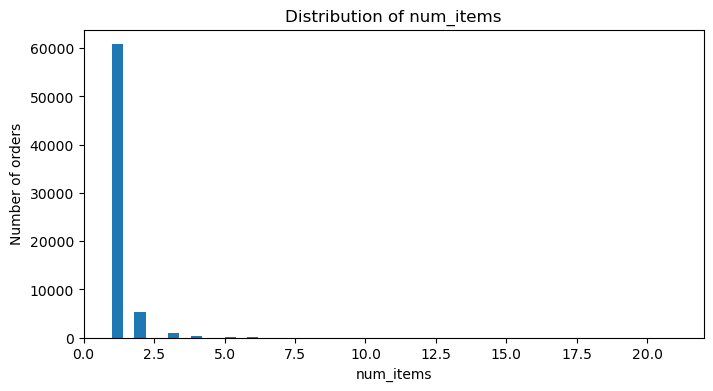

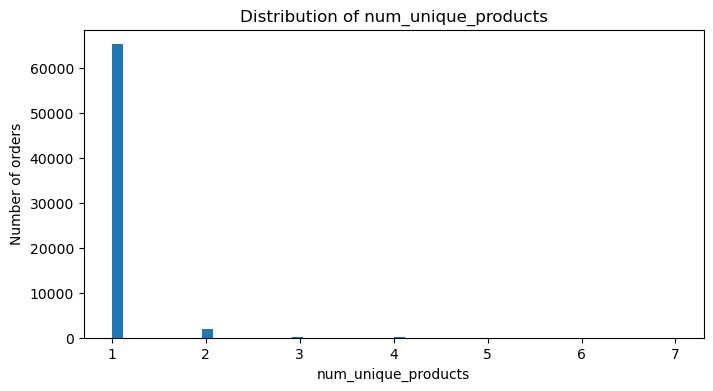

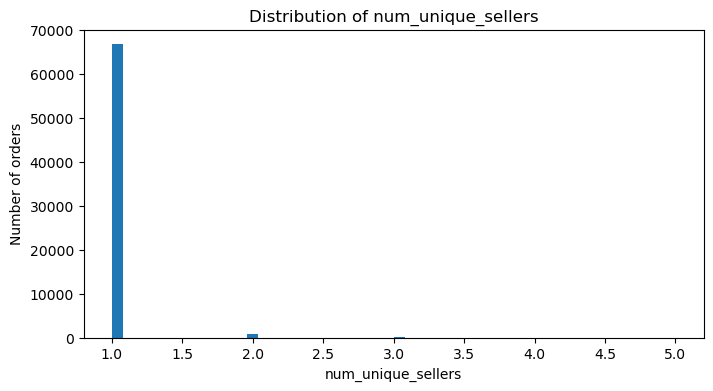

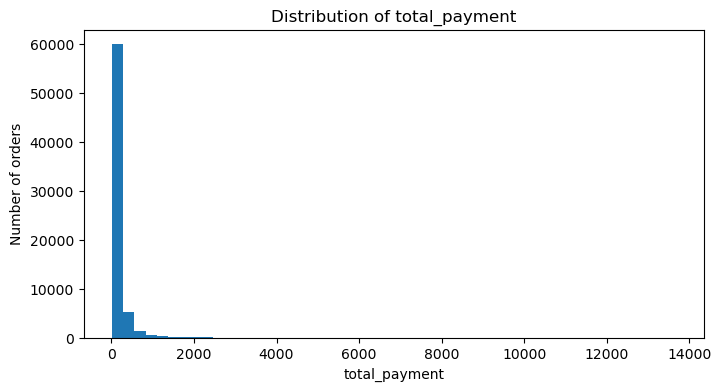

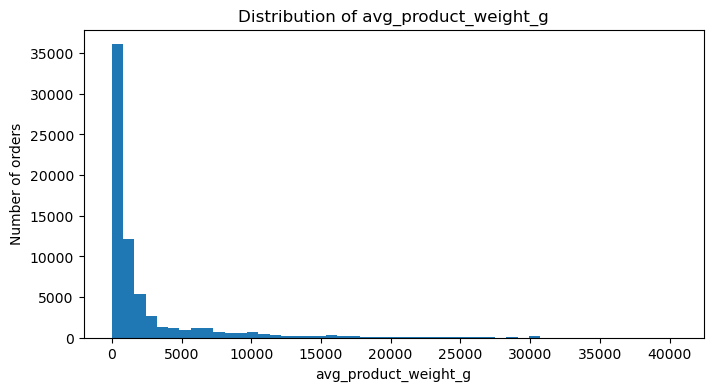

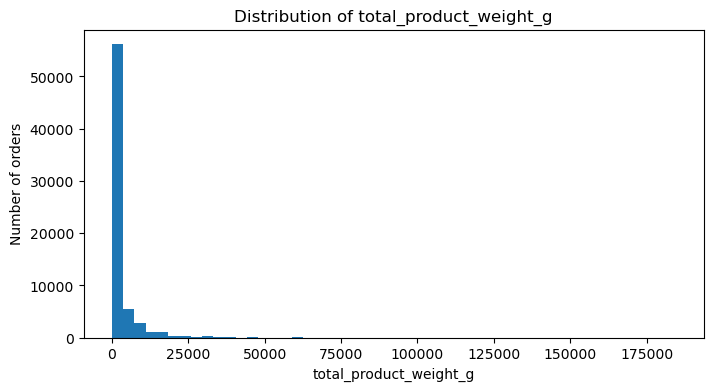

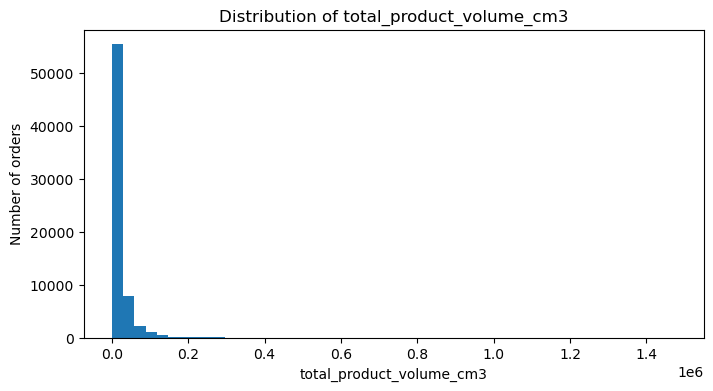

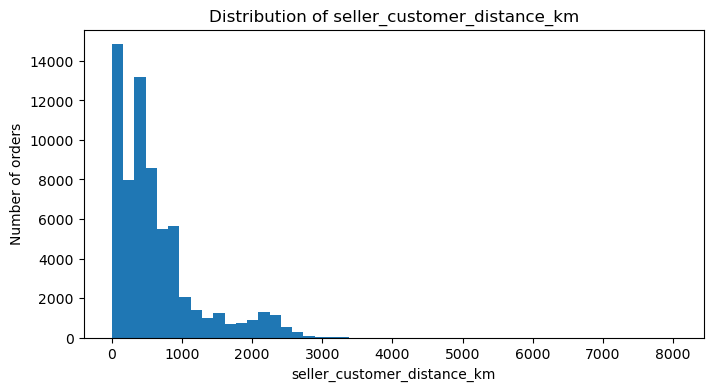

In [15]:
numeric_features = [
    "total_price",
    "total_freight",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "total_payment",
    "avg_product_weight_g",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "seller_customer_distance_km"
]

for col in numeric_features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        train[col].dropna(),
        bins=50
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of orders")

    plt.show()

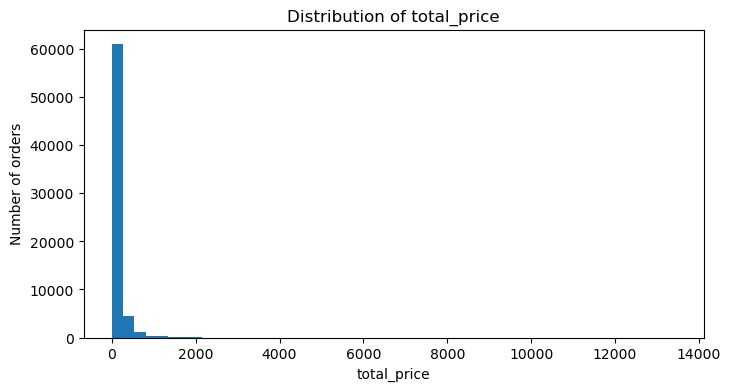

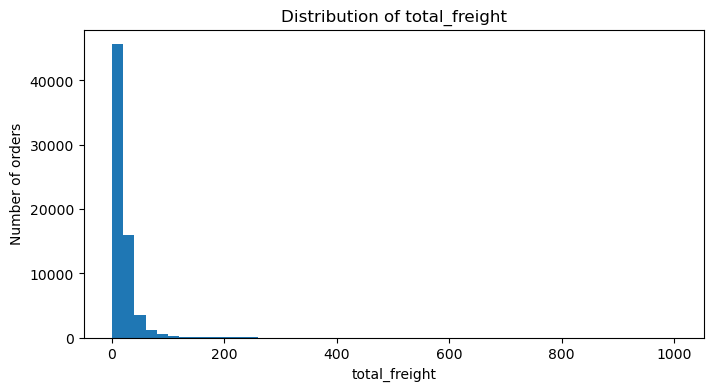

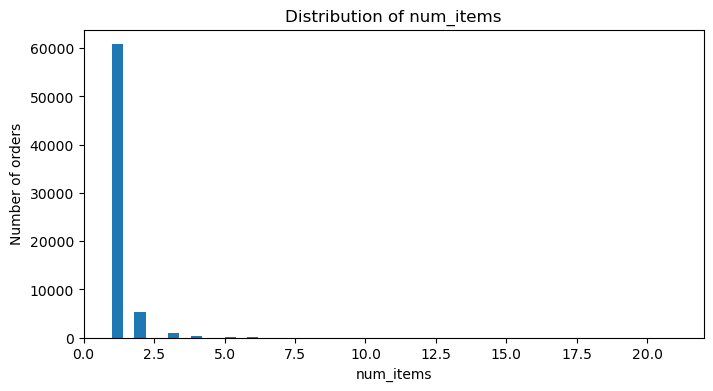

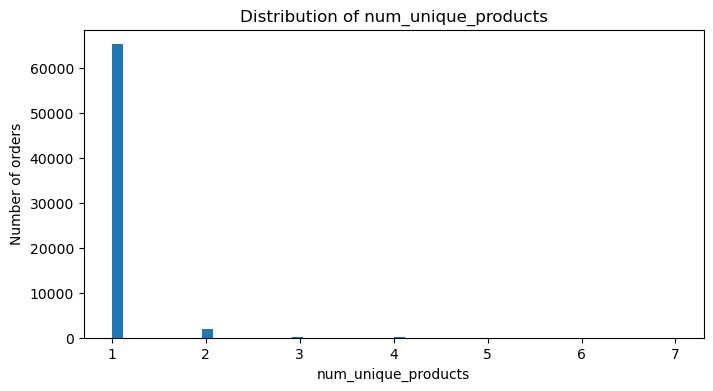

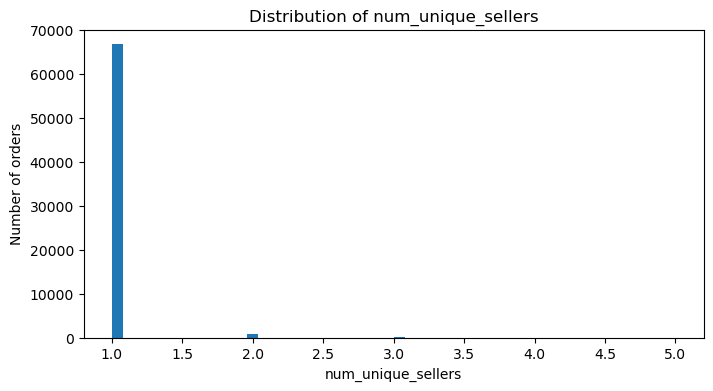

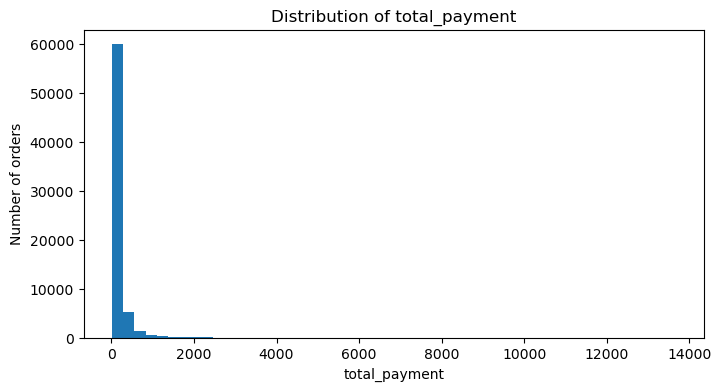

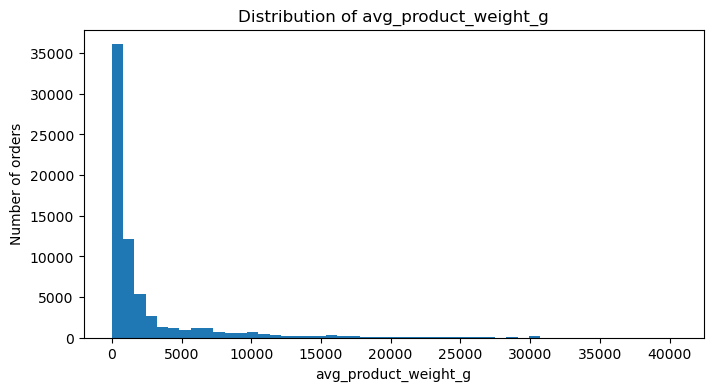

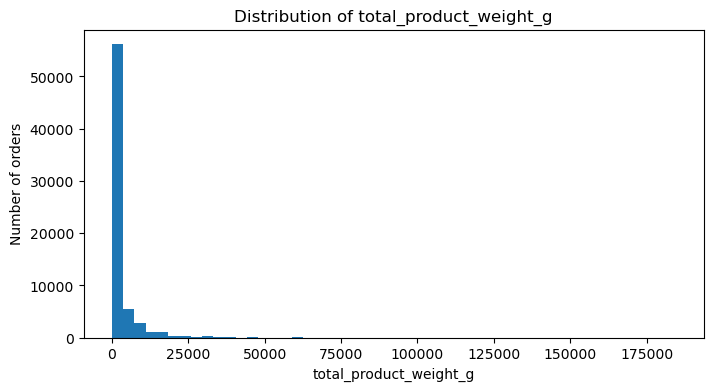

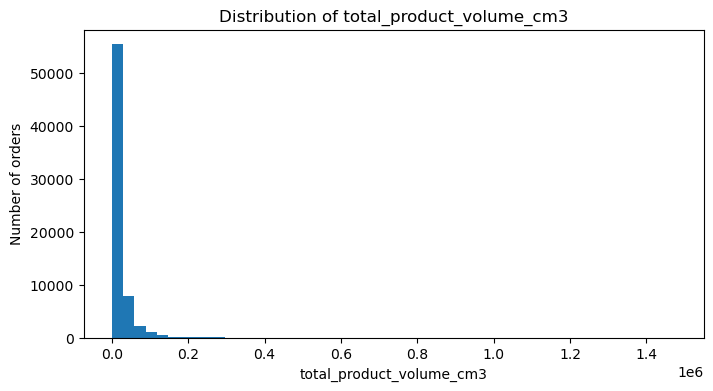

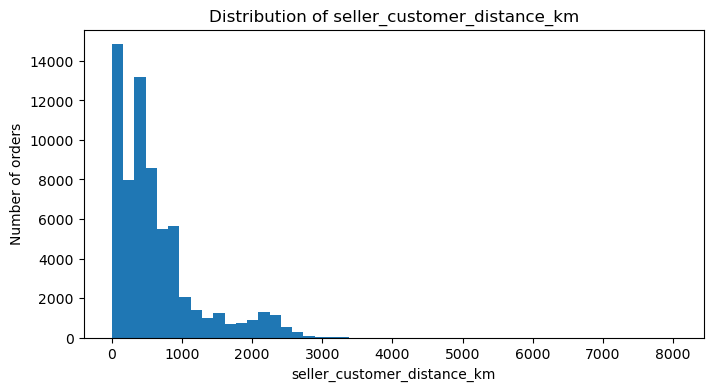

تم ضغط جميع الصور بنجاح في ملف charts_archive.zip!


In [17]:
import shutil
import os

# إنشاء مجلد باسم "my_charts" إذا لم يكن موجوداً
output_dir = "my_charts"
os.makedirs(output_dir, exist_ok=True)

numeric_features = [
    "total_price",
    "total_freight",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "total_payment",
    "avg_product_weight_g",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "seller_customer_distance_km"
]

for col in numeric_features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        train[col].dropna(),
        bins=50
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of orders")
    
    # سطر الحفظ الذكي: يحفظ كل صورة باسم العمود الخاص بها
    plt.savefig(f"{output_dir}/{col}_chart.png", dpi=300, bbox_inches="tight")
    plt.show()

shutil.make_archive("charts_archive", 'zip', output_dir)
print("تم ضغط جميع الصور بنجاح في ملف charts_archive.zip!")

In [21]:
numeric_features = [
    "total_price",
    "total_freight",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "total_payment",
    "num_payment_records",
    "num_payment_types",
    "avg_product_weight_g",
    "total_product_weight_g",
    "avg_product_length_cm",
    "avg_product_height_cm",
    "avg_product_width_cm",
    "total_product_volume_cm3",
    "seller_customer_distance_km"
]

In [22]:
skewness = (
    train[numeric_features]
    .skew()
    .sort_values(ascending=False)
)

display(skewness)

num_payment_records            22.420165
total_price                    10.719309
num_unique_sellers             10.525258
total_payment                  10.149896
total_freight                   8.584291
num_items                       8.106935
num_unique_products             7.675360
total_product_volume_cm3        7.556231
total_product_weight_g          6.645649
num_payment_types               6.217825
avg_product_weight_g            3.579818
avg_product_height_cm           2.213530
avg_product_width_cm            1.726699
avg_product_length_cm           1.722199
seller_customer_distance_km     1.683493
dtype: float64

In [19]:
outlier_summary = []

for col in numeric_features:

    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = (
        (train[col] < lower) |
        (train[col] > upper)
    ).sum()

    outlier_pct = (
        outlier_count /
        train[col].notna().sum()
    ) * 100

    outlier_summary.append({
        "feature": col,
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_pct, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(
    outlier_summary.sort_values(
        "outlier_percent",
        ascending=False
    )
)

,feature,outlier_count,outlier_percent
6,avg_product_weight_g,9768,14.47
7,total_product_weight_g,9508,14.08
2,num_items,6759,10.01
1,total_freight,6629,9.82
8,total_product_volume_cm3,6620,9.80
9,seller_customer_distance_km,5446,8.11
0,total_price,5361,7.94
5,total_payment,5308,7.86
3,num_unique_products,2210,3.27
4,num_unique_sellers,776,1.15


In [23]:
corr = train[numeric_features + ["is_delayed"]].corr()

display(corr)

,total_price,total_freight,num_items,num_unique_products,num_unique_sellers,total_payment,num_payment_records,num_payment_types,avg_product_weight_g,total_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,total_product_volume_cm3,seller_customer_distance_km,is_delayed
total_price,1.000000,0.414521,0.155733,0.056311,0.039235,0.996354,0.000037,-0.008796,0.330830,0.347153,0.134099,0.234187,0.170346,0.310215,0.078558,0.021315
total_freight,0.414521,1.000000,0.475176,0.208000,0.122014,0.490457,0.000196,-0.006100,0.512347,0.659873,0.244260,0.336545,0.261050,0.655761,0.313542,0.046604
num_items,0.155733,0.475176,1.000000,0.457178,0.260587,0.193599,-0.003912,-0.008109,-0.006800,0.223144,0.011801,0.010155,-0.005541,0.279107,-0.013306,-0.016146
num_unique_products,0.056311,0.208000,0.457178,1.000000,0.562566,0.073438,0.007668,0.005582,-0.018926,0.075160,-0.004541,-0.032129,0.005728,0.098412,-0.013569,-0.021611
num_unique_sellers,0.039235,0.122014,0.260587,0.562566,1.000000,0.049134,0.017610,0.013014,-0.009692,0.042185,0.004082,-0.009666,0.003001,0.058002,-0.011121,-0.025872
total_payment,0.996354,0.490457,0.193599,0.073438,0.049134,1.000000,0.000039,-0.009013,0.364738,0.394113,0.151338,0.255676,0.187549,0.358342,0.104555,0.024756
num_payment_records,0.000037,0.000196,-0.003912,0.007668,0.017610,0.000039,1.000000,0.533913,0.009592,0.007092,0.011174,0.005311,0.011693,0.008683,-0.001393,-0.005894
num_payment_types,-0.008796,-0.006100,-0.008109,0.005582,0.013014,-0.009013,0.533913,1.000000,-0.003974,-0.006318,0.005494,-0.003023,0.003452,-0.005506,0.007469,-0.007228
avg_product_weight_g,0.330830,0.512347,-0.006800,-0.018926,-0.009692,0.364738,0.009592,-0.003974,1.000000,0.884638,0.450579,0.582202,0.508162,0.692452,-0.005310,0.025670
total_product_weight_g,0.347153,0.659873,0.223144,0.075160,0.042185,0.394113,0.007092,-0.006318,0.884638,1.000000,0.401198,0.526963,0.444255,0.822896,-0.007465,0.019399


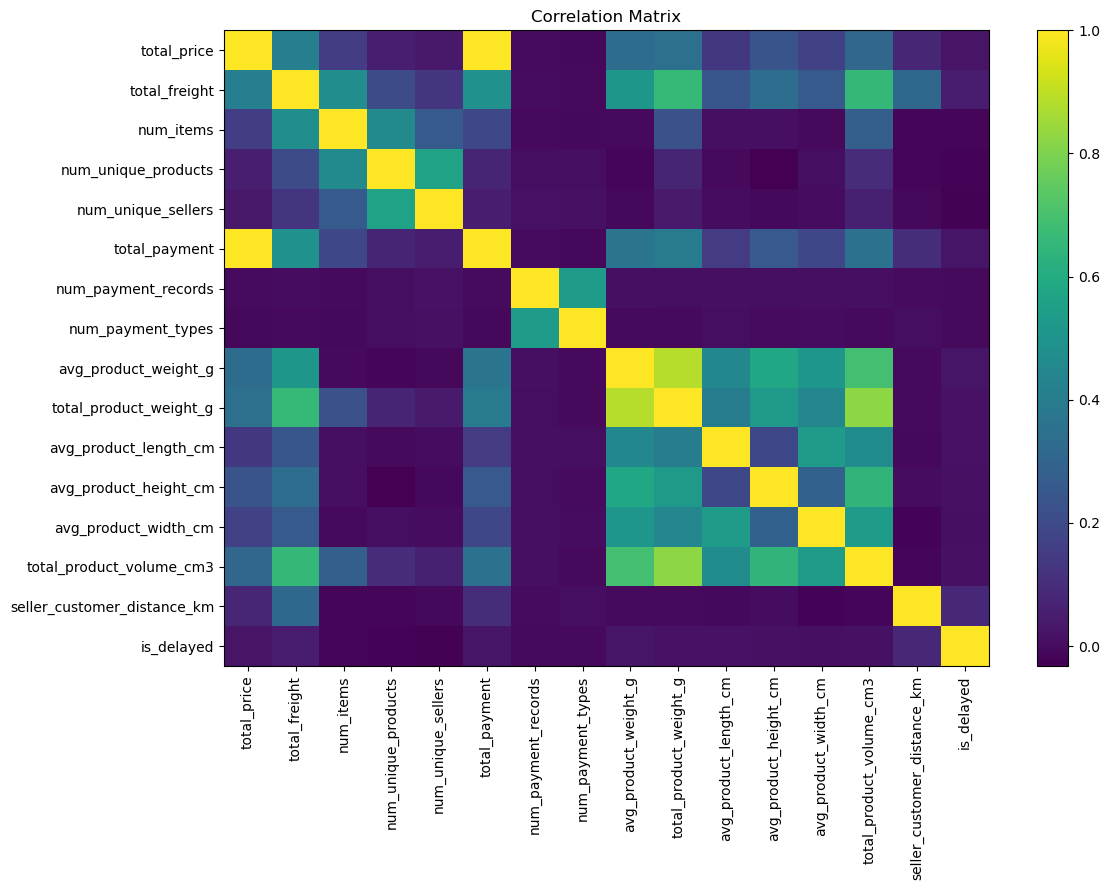

In [24]:
plt.figure(figsize=(12, 9))

plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [25]:
feature_delay_summary = []

for col in numeric_features:

    grouped = train.groupby("is_delayed")[col].agg(
        mean="mean",
        median="median"
    )

    feature_delay_summary.append({
        "feature": col,
        "on_time_mean": grouped.loc[0, "mean"],
        "delayed_mean": grouped.loc[1, "mean"],
        "on_time_median": grouped.loc[0, "median"],
        "delayed_median": grouped.loc[1, "median"]
    })

feature_delay_summary = pd.DataFrame(
    feature_delay_summary
)

display(feature_delay_summary)

,feature,on_time_mean,delayed_mean,on_time_median,delayed_median
0,total_price,134.506741,149.767376,84.990000,89.990000
1,total_freight,21.950632,25.202941,16.600000,18.120000
2,num_items,1.144834,1.114319,1.000000,1.000000
3,num_unique_products,1.039228,1.022470,1.000000,1.000000
4,num_unique_sellers,1.012989,1.002624,1.000000,1.000000
5,total_payment,156.496706,175.007633,103.050000,113.855000
6,num_payment_records,1.048359,1.040190,1.000000,1.000000
7,num_payment_types,1.024367,1.020505,1.000000,1.000000
8,avg_product_weight_g,2140.236482,2486.513612,700.000000,800.000000
9,total_product_weight_g,2435.216192,2767.505166,800.000000,850.000000


<Figure size 800x400 with 0 Axes>

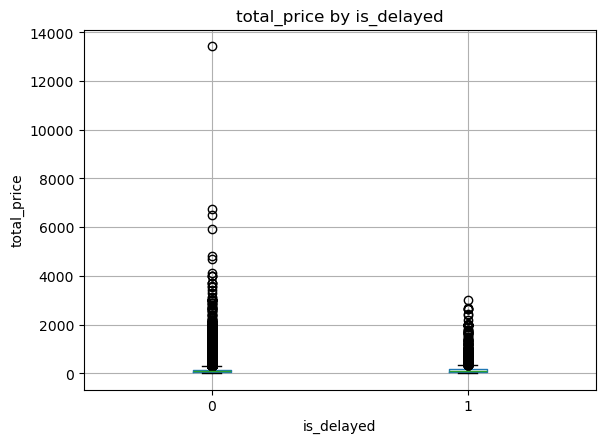

<Figure size 800x400 with 0 Axes>

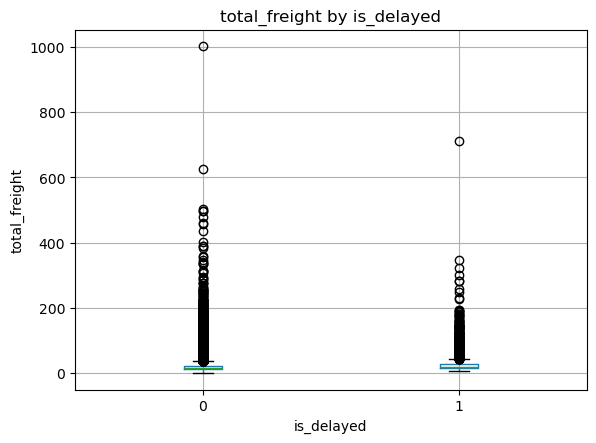

<Figure size 800x400 with 0 Axes>

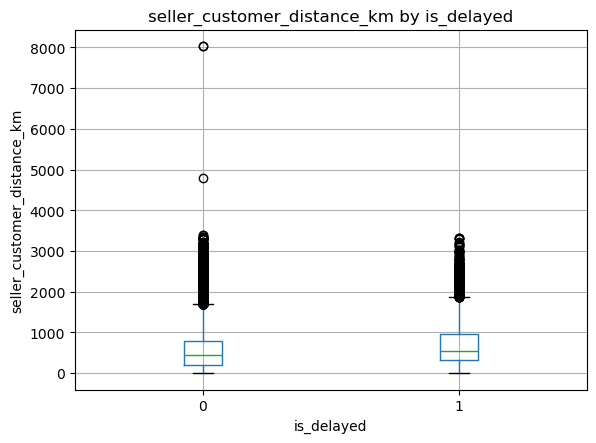

<Figure size 800x400 with 0 Axes>

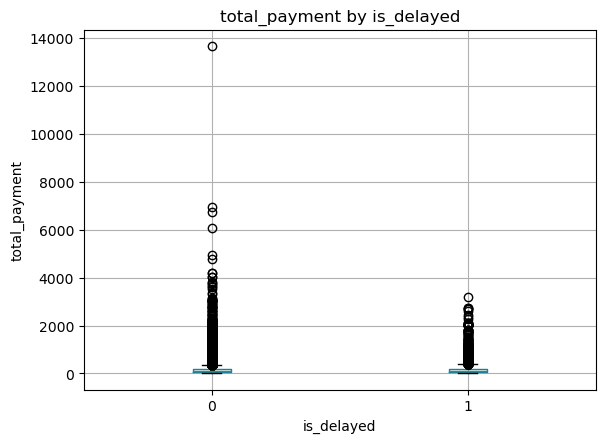

In [26]:
plot_features = [
    "total_price",
    "total_freight",
    "seller_customer_distance_km",
    "total_payment"
]

for col in plot_features:

    plt.figure(figsize=(8, 4))

    train.boxplot(
        column=col,
        by="is_delayed"
    )

    plt.title(f"{col} by is_delayed")
    plt.suptitle("")
    plt.xlabel("is_delayed")
    plt.ylabel(col)

    plt.show()

In [27]:
city_stats = (
    train.groupby("customer_city")
    .agg(
        orders=("is_delayed", "count"),
        delay_rate=("is_delayed", "mean")
    )
)

city_stats["delay_rate"] = (
    city_stats["delay_rate"] * 100
).round(2)

city_stats_filtered = city_stats[
    city_stats["orders"] >= 100
]

display(
    city_stats_filtered
    .sort_values("delay_rate", ascending=False)
    .head(15)
)

,orders,delay_rate
customer_city,,
maceio,172,35.47
sao goncalo,282,28.72
sao luis,244,23.36
macae,155,23.23
sao jose,114,22.81
teresina,189,22.75
fortaleza,454,21.81
volta redonda,163,20.86
salvador,823,19.56


In [28]:
seller_features = [
    "num_sellers",
    "num_unique_sellers",
    "num_seller_states",
    "num_seller_cities"
]

for col in seller_features:

    result = (
        train.groupby(col)["is_delayed"]
        .agg(
            orders="count",
            delay_rate="mean"
        )
    )

    result["delay_rate"] = (
        result["delay_rate"] * 100
    ).round(2)

    print("\n", "=" * 50)
    print(col)

    display(result)


num_sellers


,orders,delay_rate
num_sellers,,
1.0,66757,9.11
2.0,742,2.16
3.0,31,0.00
4.0,2,0.00
5.0,1,0.00



num_unique_sellers


,orders,delay_rate
num_unique_sellers,,
1.0,66757,9.11
2.0,742,2.16
3.0,31,0.00
4.0,2,0.00
5.0,1,0.00



num_seller_states


,orders,delay_rate
num_seller_states,,
1.0,67222,9.06
2.0,306,1.31
3.0,5,0.00



num_seller_cities


,orders,delay_rate
num_seller_cities,,
1.0,66923,9.1
2.0,588,1.7
3.0,20,0.0
4.0,2,0.0


In [29]:
product_features = [
    "avg_product_weight_g",
    "total_product_weight_g",
    "total_product_volume_cm3"
]

for col in product_features:

    result = (
        train.groupby("is_delayed")[col]
        .agg(
            count="count",
            mean="mean",
            median="median"
        )
    )

    print("\n" + "=" * 50)
    print(col)

    display(result)


avg_product_weight_g


,count,mean,median
is_delayed,,,
0,61420,2140.236482,700.0
1,6097,2486.513612,800.0



total_product_weight_g


,count,mean,median
is_delayed,,,
0,61436,2435.216192,800.0
1,6097,2767.505166,850.0



total_product_volume_cm3


,count,mean,median
is_delayed,,,
0,61436,17943.622746,7700.0
1,6097,19490.273249,8000.0


In [30]:
distance_quantiles = pd.qcut(
    train["seller_customer_distance_km"],
    q=10,
    duplicates="drop"
)

distance_quantile_delay = (
    train.groupby(
        distance_quantiles,
        observed=False
    )["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
)

display(distance_quantile_delay)

seller_customer_distance_km
(-0.001, 40.482]        4.52
(40.482, 133.876]       5.52
(133.876, 292.829]      6.88
(292.829, 354.77]       9.64
(354.77, 448.185]       8.97
(448.185, 543.817]      9.09
(543.817, 709.382]     10.88
(709.382, 886.217]      9.51
(886.217, 1467.337]    10.48
(1467.337, 8032.93]    14.67
Name: is_delayed, dtype: float64

In [31]:
train["purchase_hour"] = (
    train["order_purchase_timestamp"].dt.hour
)

hour_delay = (
    train.groupby("purchase_hour")["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
)

display(hour_delay)

purchase_hour
0     9.69
1     8.84
2     7.84
3     4.84
4     7.35
5     8.21
6     8.18
7     8.06
8     8.51
9     8.56
10    8.69
11    8.90
12    9.27
13    8.84
14    8.96
15    8.59
16    9.08
17    8.45
18    8.85
19    9.95
20    9.21
21    9.78
22    9.40
23    9.72
Name: is_delayed, dtype: float64

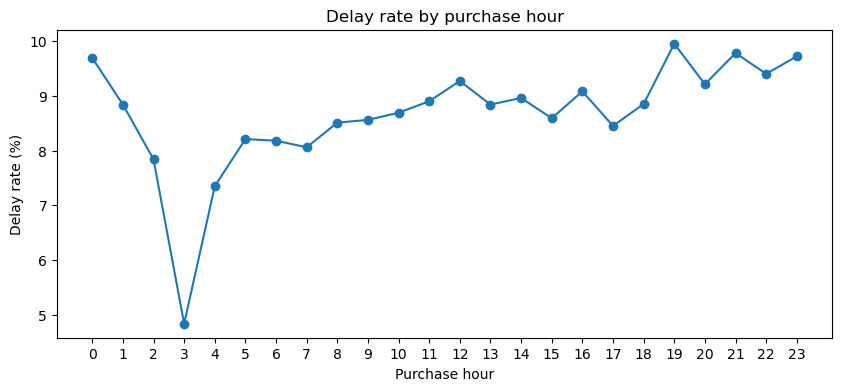

In [32]:
plt.figure(figsize=(10, 4))

hour_delay.plot(
    kind="line",
    marker="o"
)

plt.title("Delay rate by purchase hour")
plt.xlabel("Purchase hour")
plt.ylabel("Delay rate (%)")
plt.xticks(range(24))

plt.show()

In [33]:
train["purchase_hour"] = (
    train["order_purchase_timestamp"].dt.hour
)

hour_delay = (
    train.groupby("purchase_hour")["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
)

display(hour_delay)

purchase_hour
0     9.69
1     8.84
2     7.84
3     4.84
4     7.35
5     8.21
6     8.18
7     8.06
8     8.51
9     8.56
10    8.69
11    8.90
12    9.27
13    8.84
14    8.96
15    8.59
16    9.08
17    8.45
18    8.85
19    9.95
20    9.21
21    9.78
22    9.40
23    9.72
Name: is_delayed, dtype: float64

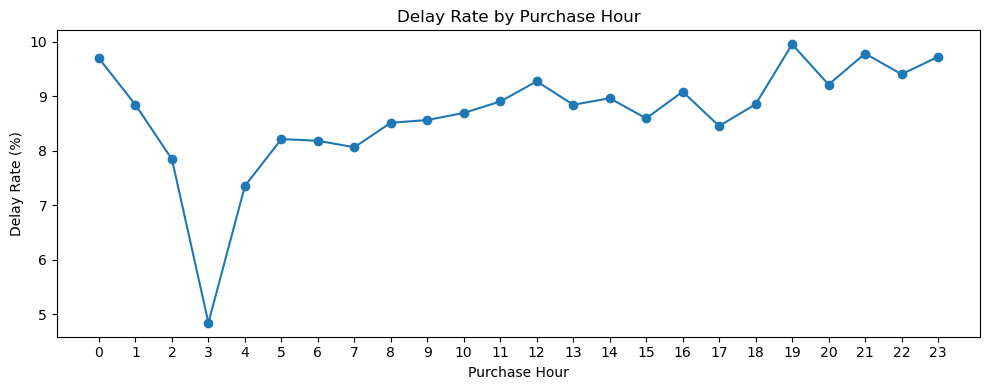

In [34]:
import os

os.makedirs(
    "data/artifacts/eda",
    exist_ok=True
)

plt.figure(figsize=(10, 4))

hour_delay.plot(
    kind="line",
    marker="o"
)

plt.title("Delay Rate by Purchase Hour")
plt.xlabel("Purchase Hour")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(24))

plt.tight_layout()

plt.savefig(
    "data/artifacts/eda/delay_rate_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [36]:
additional_features = [
    "num_unique_products",
    "num_unique_sellers",
    "total_payment",
    "num_payment_records",
    "num_payment_types",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "num_sellers",
    "num_seller_states",
    "num_seller_cities"
]

for col in additional_features:

    print("\n" + "=" * 60)
    print(col)

    display(
        train.groupby("is_delayed")[col]
        .agg(
            count="count",
            mean="mean",
            median="median"
        )
    )


num_unique_products


,count,mean,median
is_delayed,,,
0,61436,1.039228,1.0
1,6097,1.022470,1.0



num_unique_sellers


,count,mean,median
is_delayed,,,
0,61436,1.012989,1.0
1,6097,1.002624,1.0



total_payment


...

,count,mean,median
is_delayed,,,
0,61436,1.012989,1.0
1,6097,1.002624,1.0



num_seller_states


,count,mean,median
is_delayed,,,
0,61436,1.005078,1.0
1,6097,1.000656,1.0



num_seller_cities


,count,mean,median
is_delayed,,,
0,61436,1.010157,1.0
1,6097,1.001640,1.0


In [37]:
seller_features = [
    "num_sellers",
    "num_seller_states",
    "num_seller_cities"
]

for col in seller_features:

    result = (
        train.groupby(col)["is_delayed"]
        .agg(
            orders="count",
            delay_rate="mean"
        )
    )

    result["delay_rate"] = (
        result["delay_rate"]
        .mul(100)
        .round(2)
    )

    print("\n" + "=" * 60)
    print(col)

    display(result)


num_sellers


,orders,delay_rate
num_sellers,,
1.0,66757,9.11
2.0,742,2.16
3.0,31,0.00
4.0,2,0.00
5.0,1,0.00



num_seller_states


,orders,delay_rate
num_seller_states,,
1.0,67222,9.06
2.0,306,1.31
3.0,5,0.00



num_seller_cities


,orders,delay_rate
num_seller_cities,,
1.0,66923,9.1
2.0,588,1.7
3.0,20,0.0
4.0,2,0.0


In [38]:
product_features = [
    "avg_product_weight_g",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "avg_product_length_cm",
    "avg_product_height_cm",
    "avg_product_width_cm",
    "avg_product_photos_qty",
    "avg_product_name_length",
    "avg_product_description_length"
]

for col in product_features:

    print("\n" + "=" * 60)
    print(col)

    display(
        train.groupby("is_delayed")[col]
        .agg(
            count="count",
            mean="mean",
            median="median"
        )
    )


avg_product_weight_g


,count,mean,median
is_delayed,,,
0,61420,2140.236482,700.0
1,6097,2486.513612,800.0



total_product_weight_g


,count,mean,median
is_delayed,,,
0,61436,2435.216192,800.0
1,6097,2767.505166,850.0



total_product_volume_cm3


...

,count,mean,median
is_delayed,,,
0,60353,2.249309,2.0
1,5983,2.204210,1.0



avg_product_name_length


,count,mean,median
is_delayed,,,
0,60353,48.706163,52.0
1,5983,49.058256,52.0



avg_product_description_length


,count,mean,median
is_delayed,,,
0,60353,778.188323,593.0
1,5983,774.739347,586.0


In [39]:
city_stats = (
    train.groupby("customer_city")
    .agg(
        orders=("is_delayed", "count"),
        delay_rate=("is_delayed", "mean")
    )
)

city_stats["delay_rate"] = (
    city_stats["delay_rate"]
    .mul(100)
    .round(2)
)

city_stats_filtered = city_stats[
    city_stats["orders"] >= 100
]

display(
    city_stats_filtered
    .sort_values(
        "delay_rate",
        ascending=False
    )
    .head(15)
)

,orders,delay_rate
customer_city,,
maceio,172,35.47
sao goncalo,282,28.72
sao luis,244,23.36
macae,155,23.23
sao jose,114,22.81
teresina,189,22.75
fortaleza,454,21.81
volta redonda,163,20.86
salvador,823,19.56


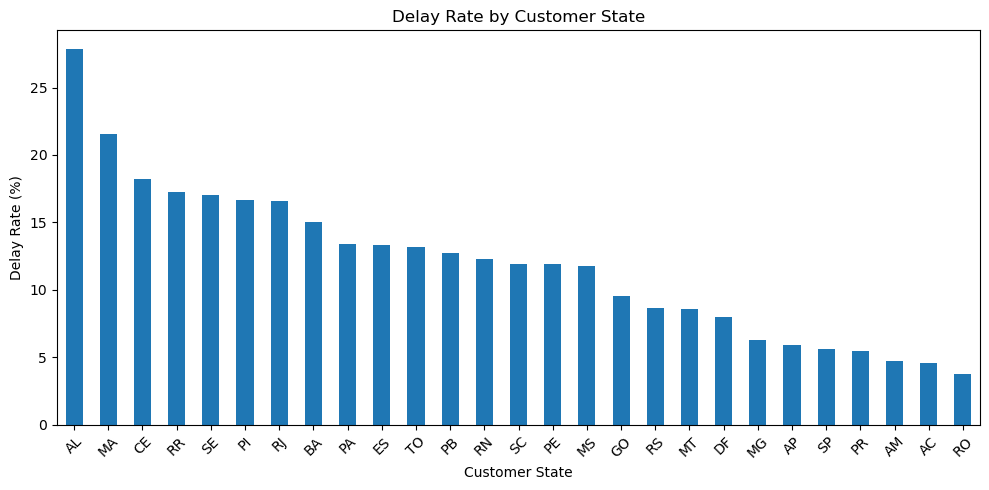

In [40]:
plt.figure(figsize=(10, 5))

state_delay["delay_rate"].sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.title("Delay Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "data/artifacts/eda/delay_rate_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

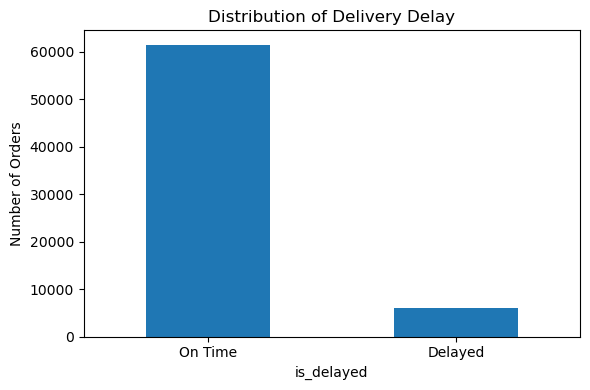

In [41]:
plt.figure(figsize=(6, 4))

train["is_delayed"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("is_delayed")
plt.ylabel("Number of Orders")
plt.xticks(
    [0, 1],
    ["On Time", "Delayed"],
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "data/artifacts/eda/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

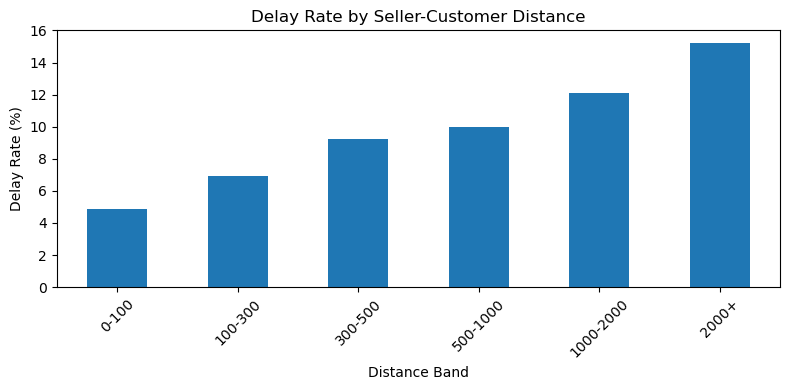

In [42]:
distance_delay = (
    train.groupby(
        "distance_band",
        observed=False
    )["is_delayed"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 4))

distance_delay.plot(
    kind="bar"
)

plt.title("Delay Rate by Seller-Customer Distance")
plt.xlabel("Distance Band")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "data/artifacts/eda/delay_rate_by_distance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

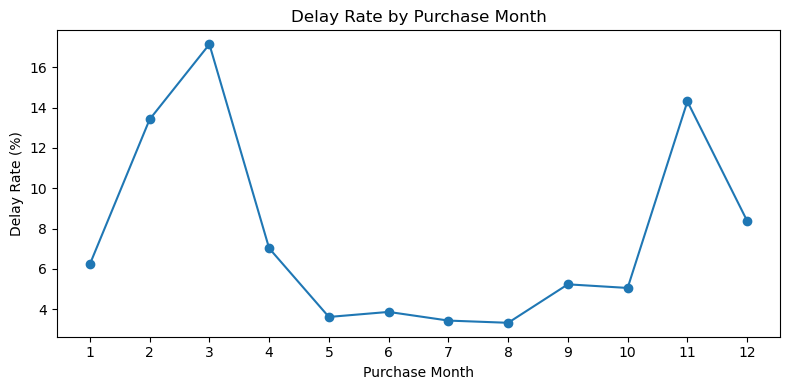

In [43]:
plt.figure(figsize=(8, 4))

monthly_delay.plot(
    kind="line",
    marker="o"
)

plt.title("Delay Rate by Purchase Month")
plt.xlabel("Purchase Month")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(1, 13))

plt.tight_layout()

plt.savefig(
    "data/artifacts/eda/delay_rate_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

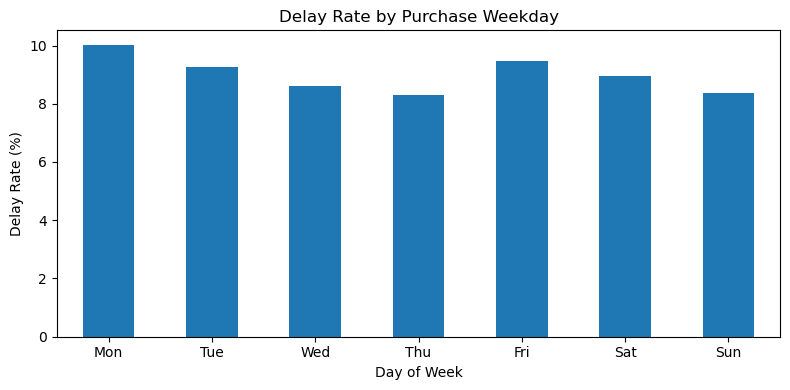

In [44]:
plt.figure(figsize=(8, 4))

weekday_delay.plot(
    kind="bar"
)

plt.title("Delay Rate by Purchase Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Delay Rate (%)")

plt.xticks(
    range(7),
    [
        "Mon", "Tue", "Wed",
        "Thu", "Fri", "Sat", "Sun"
    ],
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "data/artifacts/eda/delay_rate_by_weekday.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [46]:
corr = train[numeric_features + ["is_delayed"]].corr()

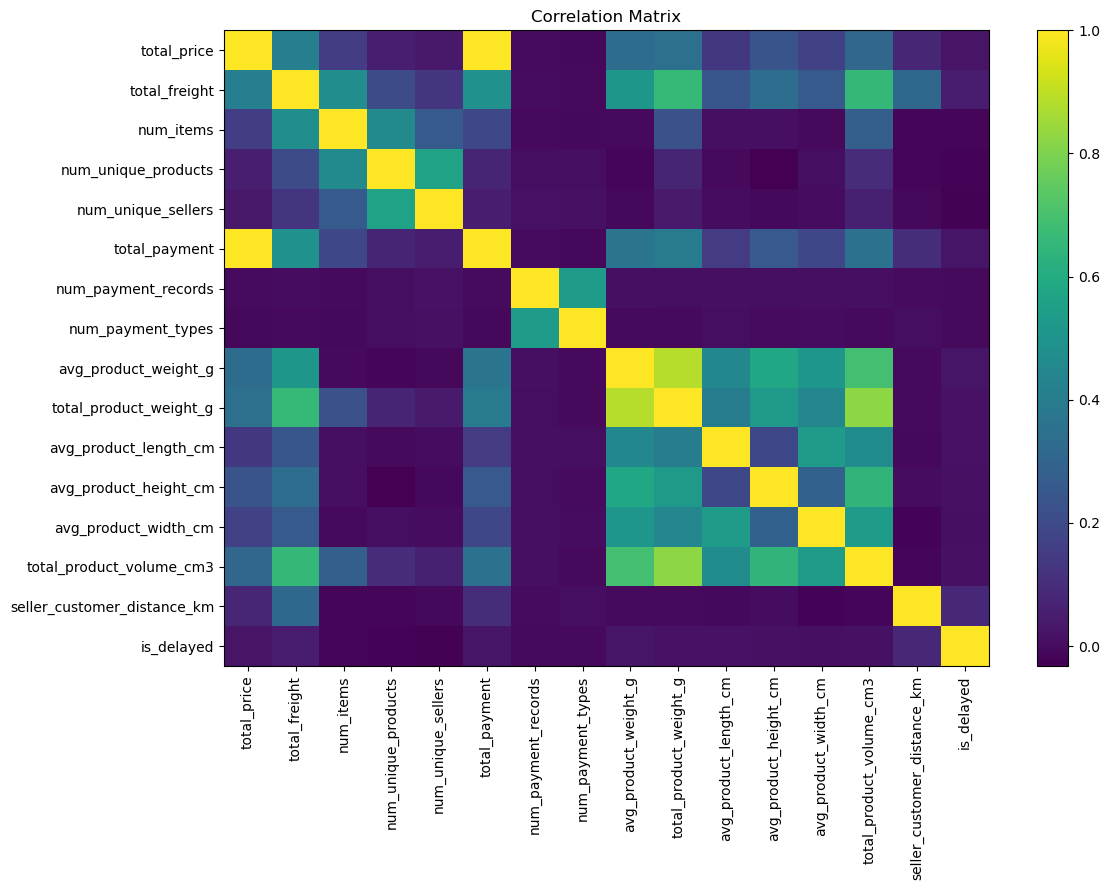

In [47]:
plt.figure(figsize=(12, 9))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "data/artifacts/eda/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

<Figure size 700x400 with 0 Axes>

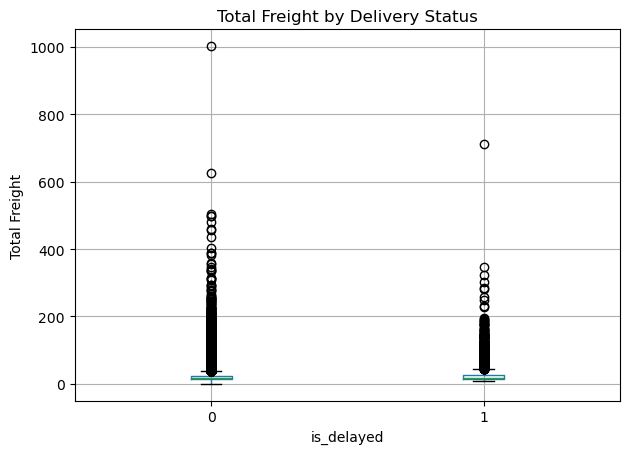

In [48]:
plt.figure(figsize=(7, 4))

train.boxplot(
    column="total_freight",
    by="is_delayed"
)

plt.title("Total Freight by Delivery Status")
plt.suptitle("")
plt.xlabel("is_delayed")
plt.ylabel("Total Freight")

plt.tight_layout()

plt.savefig(
    "data/artifacts/eda/total_freight_by_delay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

<Figure size 700x400 with 0 Axes>

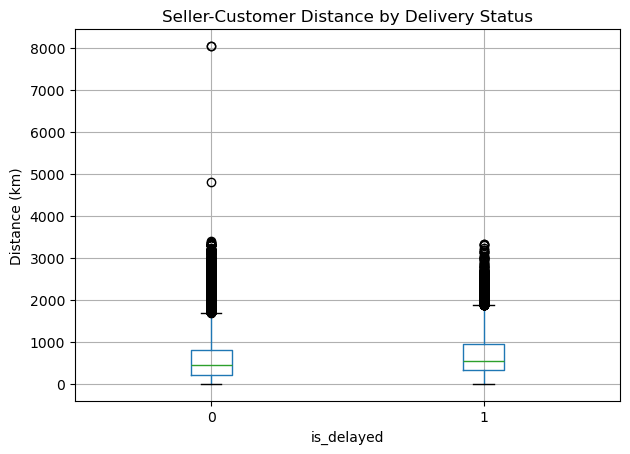

In [49]:
plt.figure(figsize=(7, 4))

train.boxplot(
    column="seller_customer_distance_km",
    by="is_delayed"
)

plt.title("Seller-Customer Distance by Delivery Status")
plt.suptitle("")
plt.xlabel("is_delayed")
plt.ylabel("Distance (km)")

plt.tight_layout()

plt.savefig(
    "data/artifacts/eda/distance_by_delay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [50]:
feature_decisions = pd.DataFrame({
    "feature": [
        "seller_customer_distance_km",
        "total_freight",
        "purchase_month",
        "purchase_weekday",
        "purchase_hour",
        "customer_state",
        "total_price",
        "total_payment",
        "num_items",
        "num_unique_products",
        "num_unique_sellers",
        "total_product_weight_g",
        "total_product_volume_cm3",
        "num_sellers"
    ],
    "decision": [
        "keep",
        "keep",
        "keep",
        "candidate",
        "candidate",
        "keep",
        "candidate",
        "candidate",
        "candidate",
        "candidate",
        "candidate",
        "candidate",
        "candidate",
        "candidate"
    ],
    "reason": [
        "Clear increase in delay rate with distance",
        "Higher values for delayed orders",
        "Strong seasonal variation",
        "Small weekday variation",
        "Evaluate after EDA",
        "Geographic differences in delay rate",
        "Slightly higher for delayed orders",
        "Highly correlated with total_price",
        "Weak observed relationship",
        "May contain order complexity information",
        "May contain order complexity information",
        "May reflect shipping difficulty",
        "May reflect shipment size",
        "May reflect multiple-seller orders"
    ]
})

display(feature_decisions)

,feature,decision,reason
0,seller_customer_distance_km,keep,Clear increase in delay rate with distance
1,total_freight,keep,Higher values for delayed orders
2,purchase_month,keep,Strong seasonal variation
3,purchase_weekday,candidate,Small weekday variation
4,purchase_hour,candidate,Evaluate after EDA
5,customer_state,keep,Geographic differences in delay rate
6,total_price,candidate,Slightly higher for delayed orders
7,total_payment,candidate,Highly correlated with total_price
8,num_items,candidate,Weak observed relationship
9,num_unique_products,candidate,May contain order complexity information


In [51]:
feature_decisions.to_csv(
    "data/artifacts/eda/feature_decisions.csv",
    index=False
)

In [52]:
findings = {
    "target": {
        "on_time_percent": 90.97,
        "delayed_percent": 9.03,
        "imbalance": "clear class imbalance"
    },

    "strong_signals": [
        "Seller-customer distance",
        "Total freight",
        "Purchase month",
        "Customer state"
    ],

    "secondary_signals": [
        "Total price",
        "Purchase weekday",
        "Purchase hour",
        "Order and product size features"
    ],

    "high_correlation_pairs": {
        "total_price_total_payment": 0.996,
        "avg_product_weight_total_product_weight": 0.885,
        "total_product_weight_total_product_volume": 0.823
    },

    "potential_leakage": [
        "order_delivered_customer_date",
        "order_delivered_carrier_date",
        "avg_review_score",
        "num_reviews"
    ],

    "identifiers_to_exclude": [
        "order_id",
        "customer_id",
        "customer_unique_id"
    ]
}

In [53]:
import json

with open(
    "data/artifacts/eda/eda_findings.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        findings,
        f,
        ensure_ascii=False,
        indent=4
    )

print("تم حفظ EDA findings.")

تم حفظ EDA findings.


In [54]:
findings_text = """
# EDA Findings

## Target and Class Imbalance
- On-time orders: 90.97%
- Delayed orders: 9.03%
- The target is imbalanced, so accuracy alone should not be used for evaluation.

## Delivery Distance
- Delay rate increased from 4.85% for 0-100 km to 15.24% for 2000+ km.
- Seller-customer distance is a strong candidate feature.

## Freight
- Delayed orders have higher total freight values.
- total_freight is a useful candidate feature.

## Seasonality
- Delay rates vary substantially by purchase month.
- March has the highest observed delay rate (17.15%).
- purchase_month is a strong candidate feature.

## Weekday and Hour
- Weekday differences are relatively small.
- Purchase hour shows some variation, but the relationship is weaker than distance and month.

## Geography
- Delay rates vary across customer states and cities.
- customer_state is a useful categorical candidate feature.
- City-level results should be interpreted carefully because some cities have relatively small sample sizes.

## Product and Order Size
- Product weight and volume are somewhat higher for delayed orders.
- Several product and order-size variables are strongly right-skewed and contain statistical outliers.
- These variables remain candidates for further evaluation.

## Feature Correlation
- total_price and total_payment are highly correlated.
- avg_product_weight_g and total_product_weight_g are highly correlated.
- total_product_weight_g and total_product_volume_cm3 are also strongly correlated.
- Redundant features should be considered carefully during feature engineering.

## Data Leakage
The following variables should not be used as predictive features because they may contain information unavailable at prediction time:
- order_delivered_customer_date
- order_delivered_carrier_date
- avg_review_score
- num_reviews

Identifiers such as order_id, customer_id, and customer_unique_id should not be used directly as predictive features.

## Preliminary Feature Set
Main candidate features:
- seller_customer_distance_km
- total_freight
- purchase_month
- customer_state
- total_price
- purchase_weekday
- purchase_hour
- total_product_weight_g
- total_product_volume_cm3
- num_items
- num_unique_products
- num_unique_sellers
"""

with open(
    "data/artifacts/eda/eda_findings.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(findings_text)

print("تم حفظ eda_findings.md")

تم حفظ eda_findings.md


## EDA Findings and Feature Selection

### Target Variable

The target variable is `is_delayed`, where `1` represents a delayed order and `0` represents an on-time order.

The training data is imbalanced:

* On-time orders: 90.97%
* Delayed orders: 9.03%

Therefore, model evaluation should not rely on accuracy alone. Precision, Recall, F1-score, and the Confusion Matrix will be considered.

### Delivery Distance

A clear increasing relationship was observed between seller-customer distance and delay rate.

The delay rate increased from 4.85% for orders within 100 km to 15.24% for orders above 2000 km.

Therefore, `seller_customer_distance_km` is selected as an important predictive feature.

### Freight Cost

Delayed orders have higher freight values than on-time orders.

The median freight value was 16.60 for on-time orders and 18.12 for delayed orders.

Therefore, `total_freight` is considered a useful predictive feature.

### Order Price

Delayed orders showed slightly higher order prices than on-time orders.

The median price was 84.99 for on-time orders and 89.99 for delayed orders.

Therefore, `total_price` is considered a candidate feature.

### Purchase Time and Seasonality

The delay rate varies considerably by purchase month. The highest delay rates were observed in March (17.15%), November (14.31%), and February (13.42%).

The difference between weekdays was relatively small, with delay rates ranging from approximately 8.29% to 10.02%.

Therefore, `purchase_month` is considered an important temporal feature, while `purchase_weekday` is a secondary candidate.

### Customer Geography

Delay rates vary across customer states. This indicates that geographic location may contain useful predictive information.

Therefore, `customer_state` is considered a candidate categorical feature.

### Product and Order Size

Variables such as `num_items`, `num_unique_products`, product weight, and product volume were examined.

`num_items` showed only a small difference between delayed and on-time orders, while product weight and volume showed strong skewness and several statistical outliers.

These variables remain candidate features and will be evaluated during Feature Engineering.

### Feature Correlation

Some numerical variables are highly correlated.

For example:

* `total_price` and `total_payment`: correlation ≈ 0.996
* `avg_product_weight_g` and `total_product_weight_g`: correlation ≈ 0.885
* `total_product_weight_g` and `total_product_volume_cm3`: correlation ≈ 0.823

These relationships indicate overlapping information. Feature selection will consider this redundancy when preparing the final feature set.

### Outliers and Skewness

Several numerical features are strongly right-skewed and contain statistical outliers.

These values were not removed during EDA because statistical outliers are not necessarily incorrect observations.

Possible transformations or preprocessing methods will be evaluated during Feature Engineering.

### Data Leakage

The following variables should not be used as predictive features because they contain information that may only become available after the prediction point:

* `order_delivered_customer_date`
* `order_delivered_carrier_date`
* `avg_review_score`
* `num_reviews`

Identifier columns such as `order_id`, `customer_id`, and `customer_unique_id` will also not be used directly as predictive features.

### Preliminary Feature Set

Based on the EDA, the main candidate features are:

* `seller_customer_distance_km`
* `total_freight`
* `purchase_month`
* `customer_state`
* `total_price`
* `purchase_weekday`
* `num_items`
* `num_unique_products`
* `num_unique_sellers`
* `total_payment`
* `total_product_weight_g`
* `total_product_volume_cm3`

The final feature set and preprocessing strategy will be determined in Notebook 5.

### Model Selection Consideration

Because the target variable is imbalanced and the dataset contains both numerical and categorical features, a classification model that can handle mixed feature types and class imbalance will be considered.

A simple baseline model will be established first, followed by model training and tuning. Evaluation will focus on metrics appropriate for the imbalanced target rather than accuracy alone.


## EDA Findings

### 1. Target and Class Imbalance

The target variable `is_delayed` is imbalanced in the training data.

* On-time orders (`is_delayed = 0`): 90.97%
* Delayed orders (`is_delayed = 1`): 9.03%

The delayed class is the minority class. Therefore, model evaluation should not rely on accuracy alone. Precision, Recall, F1-score, and the Confusion Matrix will be considered during model evaluation.

### 2. Delivery Distance

A clear relationship was observed between seller-customer distance and delivery delay.

The delay rate increased as the distance increased:

* 0–100 km: 4.85%
* 100–300 km: 6.90%
* 300–500 km: 9.23%
* 500–1000 km: 9.98%
* 1000–2000 km: 12.09%
* 2000+ km: 15.24%

This makes `seller_customer_distance_km` an important candidate feature.

### 3. Freight Cost

Delayed orders showed higher freight values than on-time orders.

* On-time median freight: 16.60
* Delayed median freight: 18.12

This suggests that `total_freight` may contain useful predictive information.

### 4. Order Price

Delayed orders had slightly higher order prices than on-time orders.

* On-time median price: 84.99
* Delayed median price: 89.99

The difference is relatively small, so `total_price` is considered a candidate feature but not one of the strongest signals identified so far.

### 5. Purchase Month and Seasonality

The delay rate varied considerably across purchase months.

The highest delay rates were observed in:

* March: 17.15%
* November: 14.31%
* February: 13.42%

Lower rates were observed in several months, including August (3.32%) and July (3.43%).

This indicates a possible seasonal pattern, making `purchase_month` a useful candidate feature.

### 6. Purchase Weekday

The delay rate varied only slightly by purchase weekday, ranging approximately from 8.29% to 10.02%.

Therefore, `purchase_weekday` may provide some information, but its relationship with delay appears weaker than the relationship observed for distance and purchase month.

### 7. Customer Geography

Delay rates varied across customer states. Some states showed substantially higher delay rates than others.

However, state-level results should be interpreted together with the number of orders in each state, because some states have relatively small sample sizes.

Therefore, `customer_state` is considered a candidate categorical feature.

### 8. Numerical Distributions and Outliers

Several numerical variables showed strong right-skewness and statistical outliers, particularly:

* `num_payment_records`
* `total_price`
* `num_unique_sellers`
* `total_payment`
* `total_freight`
* `num_items`
* `num_unique_products`
* `total_product_volume_cm3`
* `total_product_weight_g`

These values were not removed during EDA because an outlier detected statistically is not necessarily an invalid observation. Appropriate transformations or preprocessing will be considered during Feature Engineering.

### 9. Feature Correlation

Some numerical features were highly correlated with each other.

The strongest observed relationships included:

* `total_price` and `total_payment`: 0.996
* `avg_product_weight_g` and `total_product_weight_g`: 0.885
* `total_product_weight_g` and `total_product_volume_cm3`: 0.823

These relationships indicate that some variables contain overlapping information and should be considered carefully during feature selection.

### 10. Data Leakage Considerations

Some columns should not be used as predictive features because they contain information that may only become available after the prediction point.

Potential leakage variables include:

* `order_delivered_customer_date`
* `order_delivered_carrier_date`
* `avg_review_score`
* `num_reviews`

The target variable `is_delayed` will also never be included among the input features.

Identifier columns such as `order_id`, `customer_id`, and `customer_unique_id` will not be used directly as predictive features.

### 11. Preliminary Feature Selection

Based on the EDA findings, the strongest candidate features identified so far are:

* `seller_customer_distance_km`
* `total_freight`
* `purchase_month`
* `customer_state`

Additional candidate features include:

* `total_price`
* `purchase_weekday`
* `num_items`
* `num_unique_products`
* `num_unique_sellers`
* `total_payment`
* `total_product_weight_g`
* `total_product_volume_cm3`

The final feature set will be determined during Feature Engineering after considering missing values, encoding requirements, feature redundancy, and model requirements.
